## Interpretability analysis
We use model data logged in W&B to analyze predictions using SHAP values and attention weights.

In [30]:
import os
import sys
import torch
import wandb
import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sys.path.append(os.path.abspath(os.path.join('..')))
from src.LSTM.preprocess import load_data, encode_features, scale_data_new, create_sequences
from src.LSTM.network_variants import LSTMAttentionModel 

sns.set_style("darkgrid")
sns.set_palette("muted")

def log_run_data(run_id, entity = "ml-for-data-analytics-project", project = "energy-forecasting"):
    """Downloads model, scaler, and prediction table from W&B."""
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    config = run.config

    artifact = api.artifact(f"{entity}/{project}/trained_model_{config["run_name"]}:latest")
    artifact_dir = artifact.download()
    
    table_artifact = [a for a in run.logged_artifacts() if "predictions" in a.name][0]
    df_logged = table_artifact.get("predictions").get_dataframe()

    scaler = joblib.load(os.path.join(artifact_dir, "scaler.joblib"))
    state_dict = torch.load(os.path.join(artifact_dir, "model.pth"), map_location='cpu')
    
    parent_dir = os.path.dirname(os.getcwd())
    train_df = load_data(os.path.join(parent_dir, config["data"]["train_path"]))
    test_df = load_data(os.path.join(parent_dir, config["data"]["test_path"]))
    
    train_df, test_df = encode_features(train_df, test_df, resolution=config["data"]["resolution"])
    train_df, test_df, _ = scale_data_new(train_df, test_df)

    lags = config["data"]["lags"]
    _, _, _, Xp_test, Xf_test, _ = create_sequences(
        train_df, test_df, k=lags[-1], resolution=config["data"]["resolution"]
    )
    
    return run, config, Xp_test, Xf_test, df_logged, scaler, train_df.columns, state_dict

### LSTMAttentionModel

In [31]:
run_id = "n3viomoq"
run, config, Xp, Xf, df_logged, scaler, feat_names, state_dict = log_run_data(run_id)

wandb:   2 of 2 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [32]:
df_logged

,date,actual_kWh,predicted_kWh,error
0,2017-01-01 00:00:00+00:00,30.293125,28.092940,2.200185
1,2017-01-02 00:00:00+00:00,25.402792,25.379246,0.023545
2,2017-01-03 00:00:00+00:00,29.077582,25.852317,3.225265
3,2017-01-04 00:00:00+00:00,36.197584,29.758732,6.438852
4,2017-01-05 00:00:00+00:00,36.335581,31.420225,4.915356
...,...,...,...,...
60,2017-03-02 00:00:00+00:00,15.813334,17.210916,-1.397583
61,2017-03-03 00:00:00+00:00,13.449167,16.584427,-3.135260
62,2017-03-04 00:00:00+00:00,11.324375,14.333816,-3.009441
63,2017-03-05 00:00:00+00:00,13.648833,14.581368,-0.932535


In [33]:
feat_names
#future features for both daily and hourly are the last 4
future_feat_names = feat_names[-4:].tolist()
past_feat_names = feat_names[:-4].tolist()
print("Future features (date of prediciton):", ', '.join(future_feat_names))
print("Past features (t-1 and t-2):", ', '.join(past_feat_names))

Future features (date of prediciton): is_holiday_or_weekend_True, season_spring, season_summer, season_winter
Past features (t-1 and t-2): energy_demand, dishwasher, ev, freezer, grid_export, heat_pump, pv, washing_machine, temperature, radiation_direct_horizontal, radiation_diffuse_horizontal


wandb:   2 of 2 files downloaded.  
wandb:   1 of 1 files downloaded.  
C:\Users\user\AppData\Local\Temp\ipykernel_18948\2977440420.py:101: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(global_shap_kwh, global_data, feature_names=all_feature_names, plot_type="bar", show=False, plot_size=(20,10))


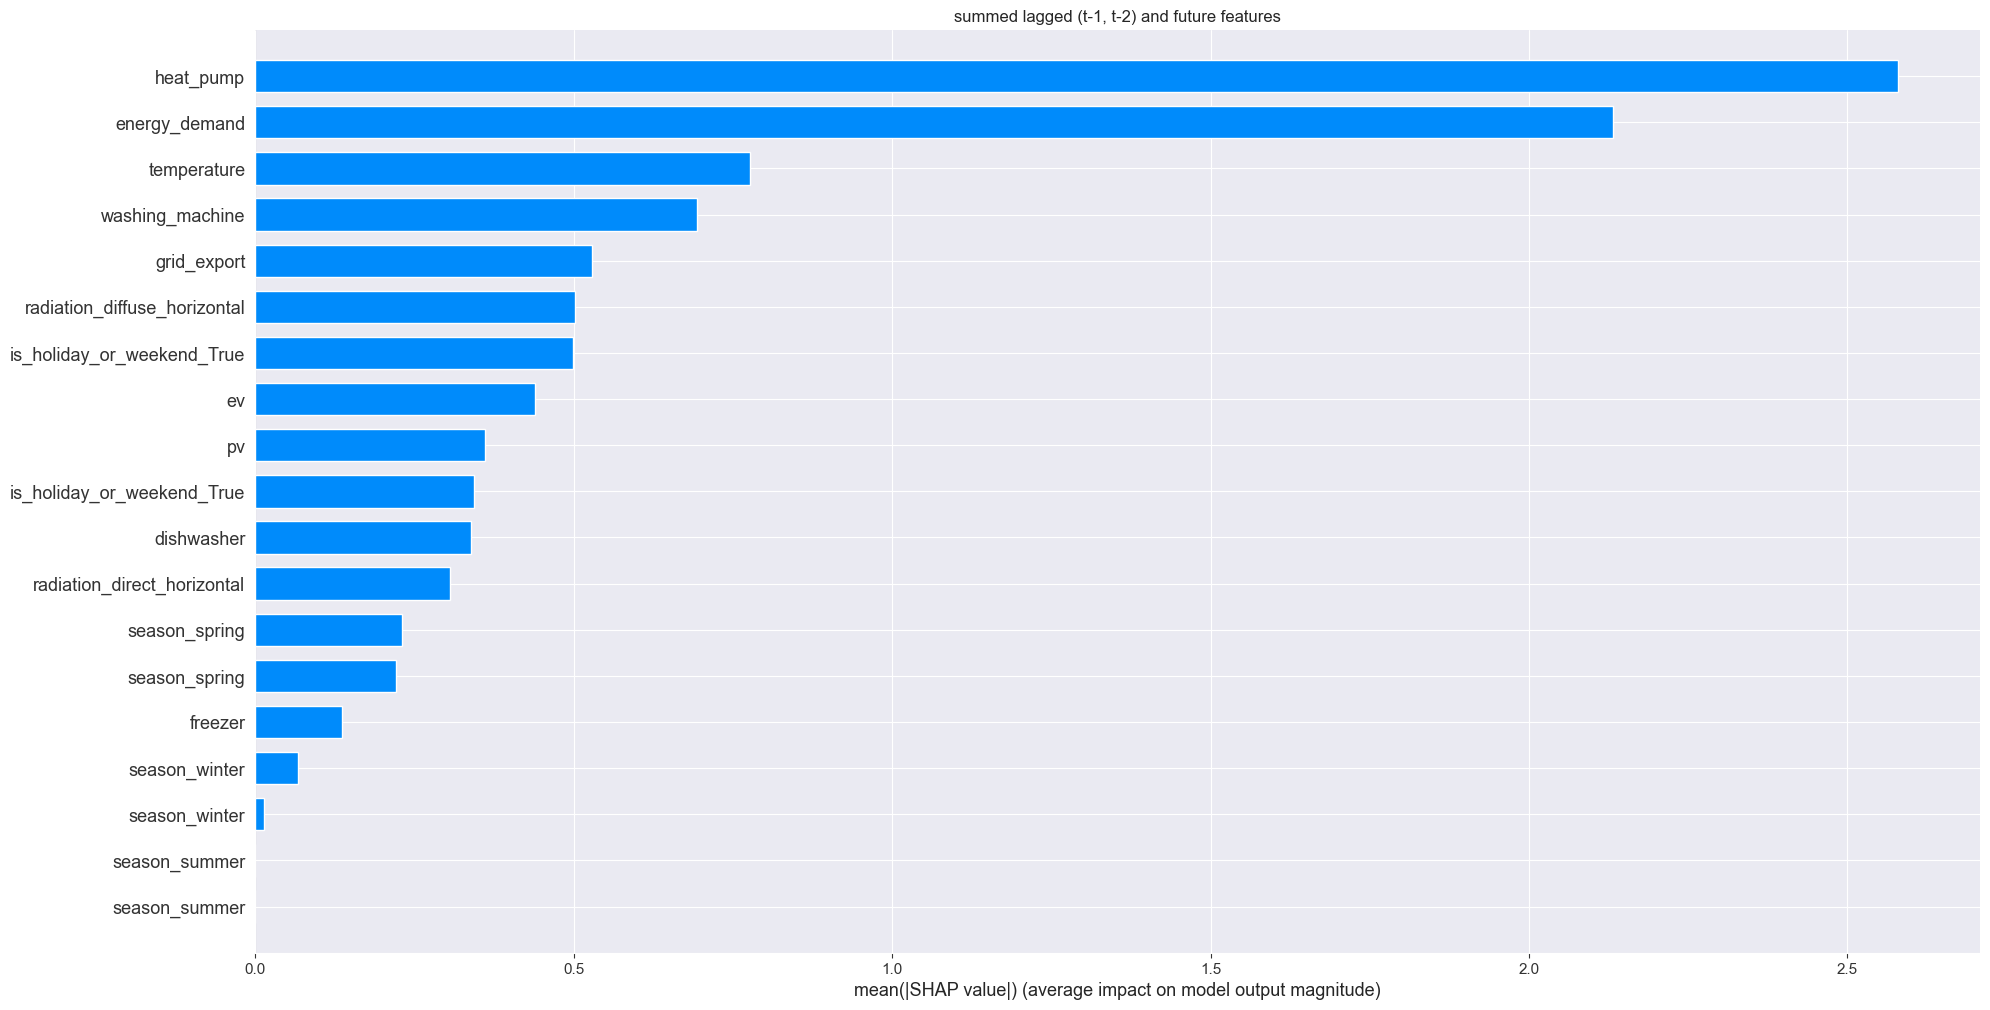

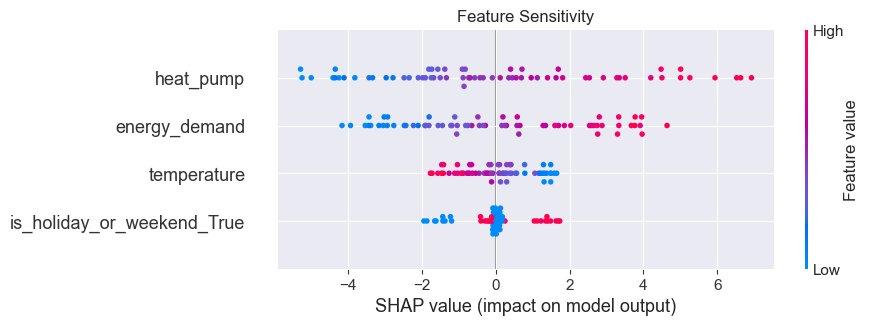

Avg attention [0.311299   0.68870103]


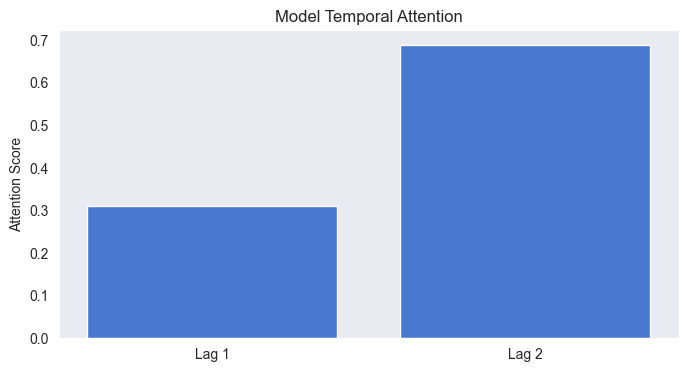


Instance 0


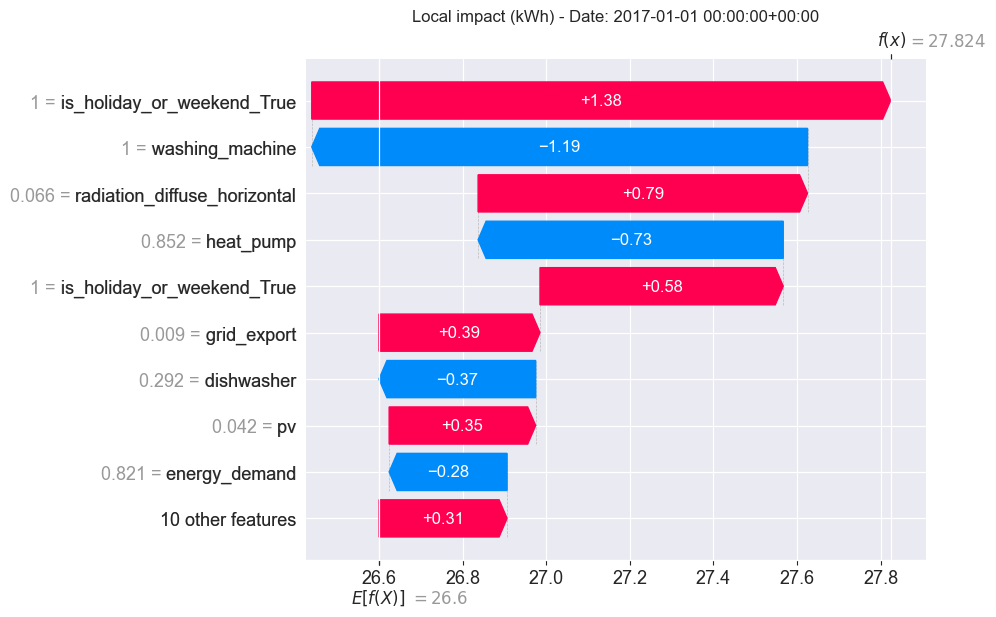

,0
date,2017-01-01 00:00:00+00:00
actual_kWh,30.293125
predicted_kWh,28.09294
error,2.200185
norm_energy_demand,0.820711
norm_dishwasher,0.292096
norm_ev,0.122902
norm_freezer,0.0
norm_grid_export,0.009274
norm_heat_pump,0.851559


training temp range: 29.86°C
0.33 shift : 9.86°C


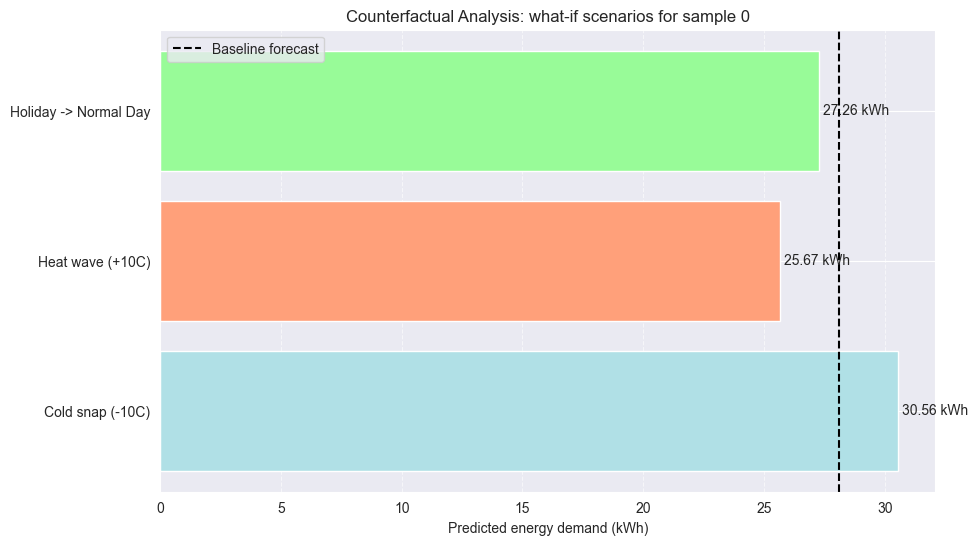


Instance 12


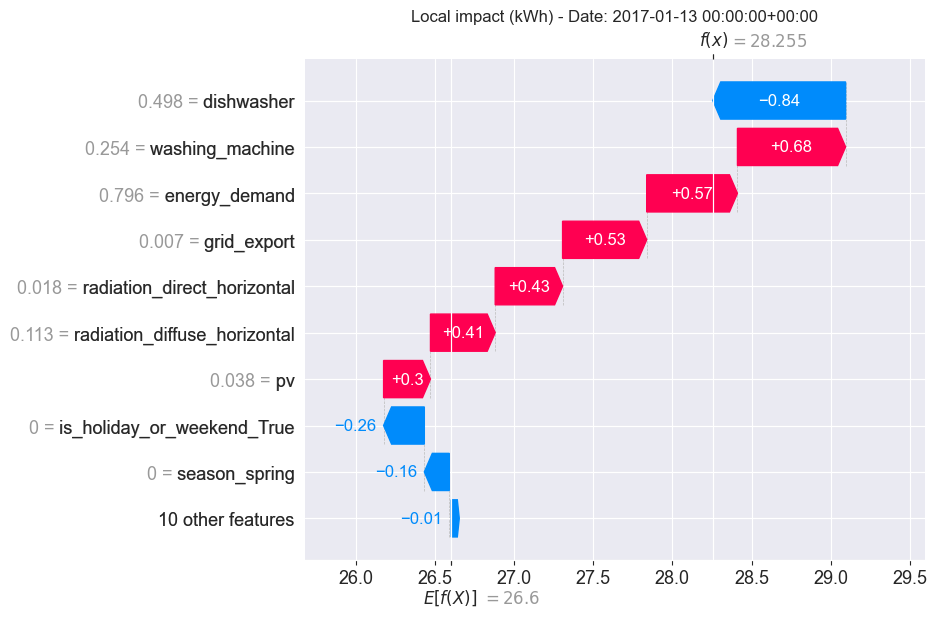

,12
date,2017-01-13 00:00:00+00:00
actual_kWh,23.850999
predicted_kWh,28.118343
error,-4.267344
norm_energy_demand,0.796218
norm_dishwasher,0.498394
norm_ev,0.242101
norm_freezer,0.023037
norm_grid_export,0.00747
norm_heat_pump,0.786229


training temp range: 29.86°C
0.33 shift : 9.86°C


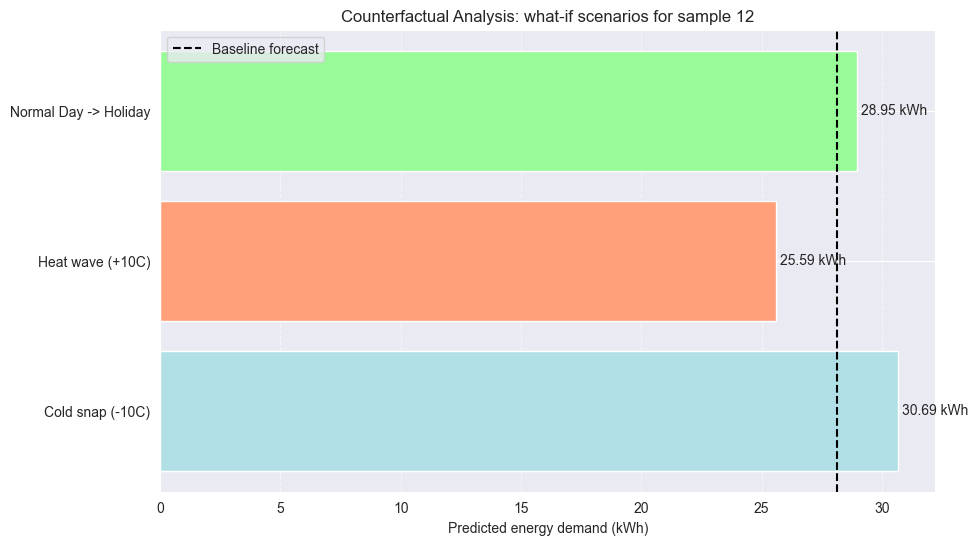


Instance 30


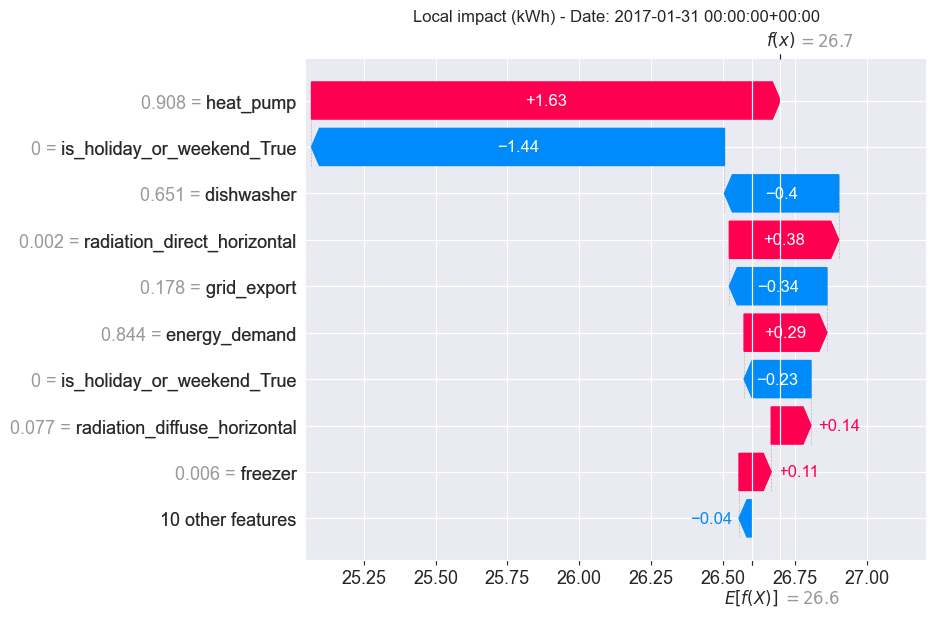

,30
date,2017-01-31 00:00:00+00:00
actual_kWh,33.096166
predicted_kWh,26.507945
error,6.588221
norm_energy_demand,0.843652
norm_dishwasher,0.651173
norm_ev,0.287887
norm_freezer,0.005602
norm_grid_export,0.178417
norm_heat_pump,0.908321


training temp range: 29.86°C
0.33 shift : 9.86°C


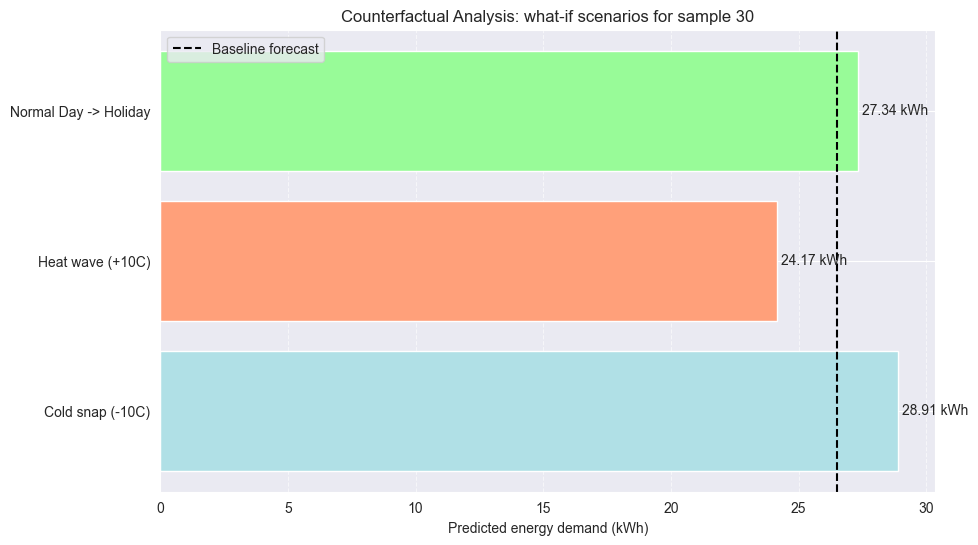


Instance 60


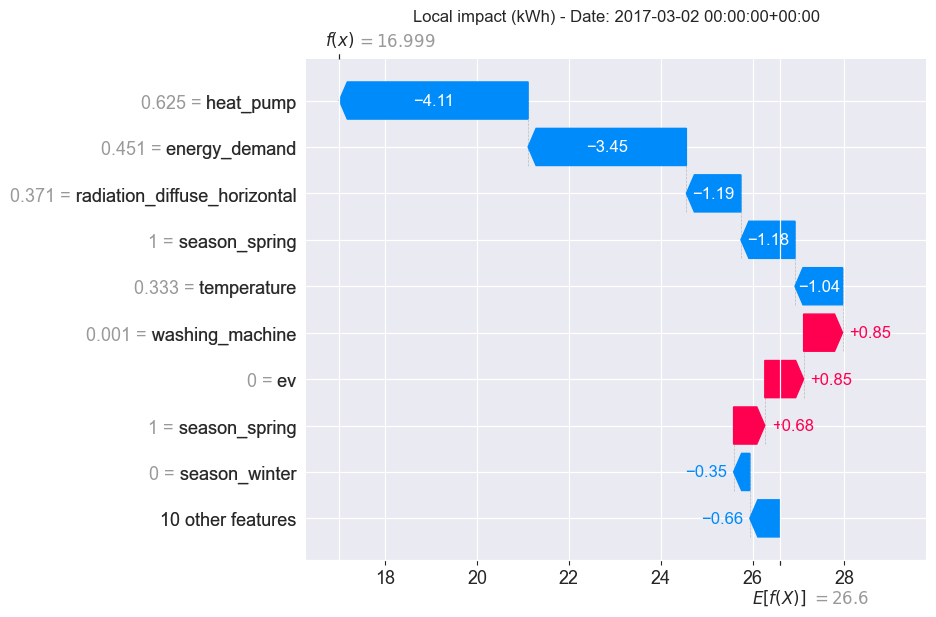

,60
date,2017-03-02 00:00:00+00:00
actual_kWh,15.813334
predicted_kWh,17.210916
error,-1.397583
norm_energy_demand,0.450739
norm_dishwasher,0.388637
norm_ev,0.0
norm_freezer,0.057988
norm_grid_export,0.128681
norm_heat_pump,0.624821


training temp range: 29.86°C
0.33 shift : 9.86°C


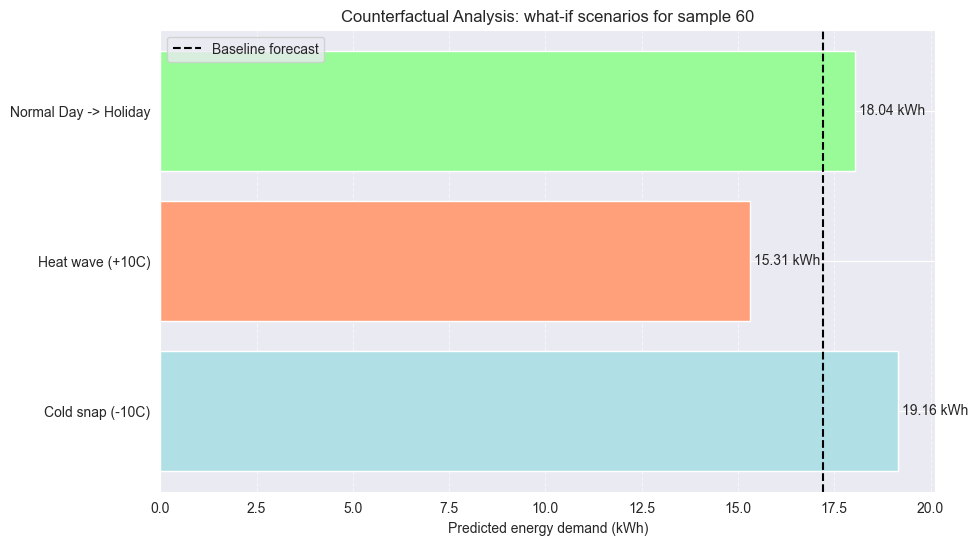


Instance 64


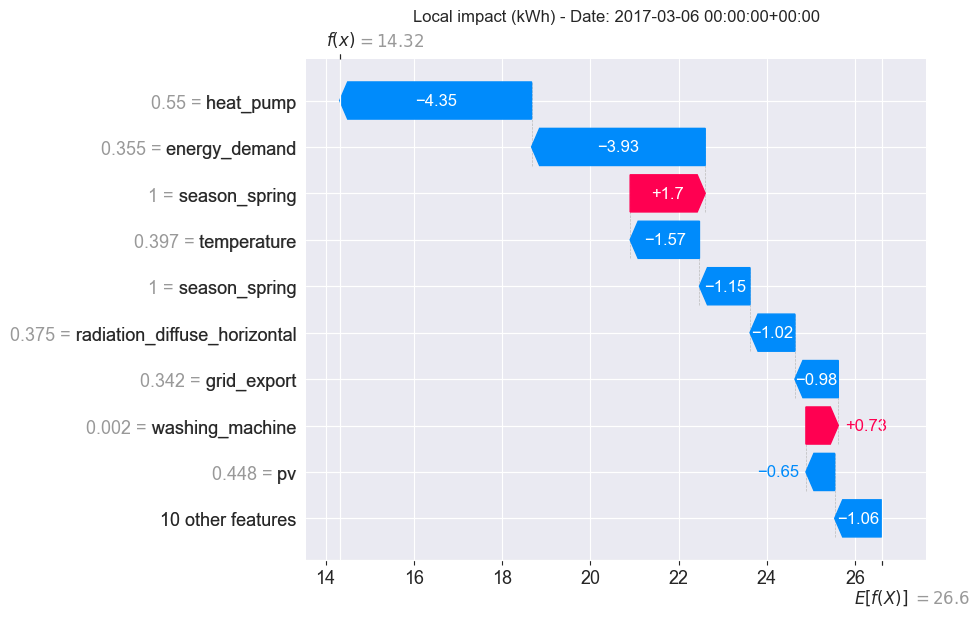

,64
date,2017-03-06 00:00:00+00:00
actual_kWh,13.378042
predicted_kWh,14.250561
error,-0.872519
norm_energy_demand,0.355094
norm_dishwasher,0.504035
norm_ev,0.263442
norm_freezer,0.084103
norm_grid_export,0.341898
norm_heat_pump,0.550332


training temp range: 29.86°C
0.33 shift : 9.86°C


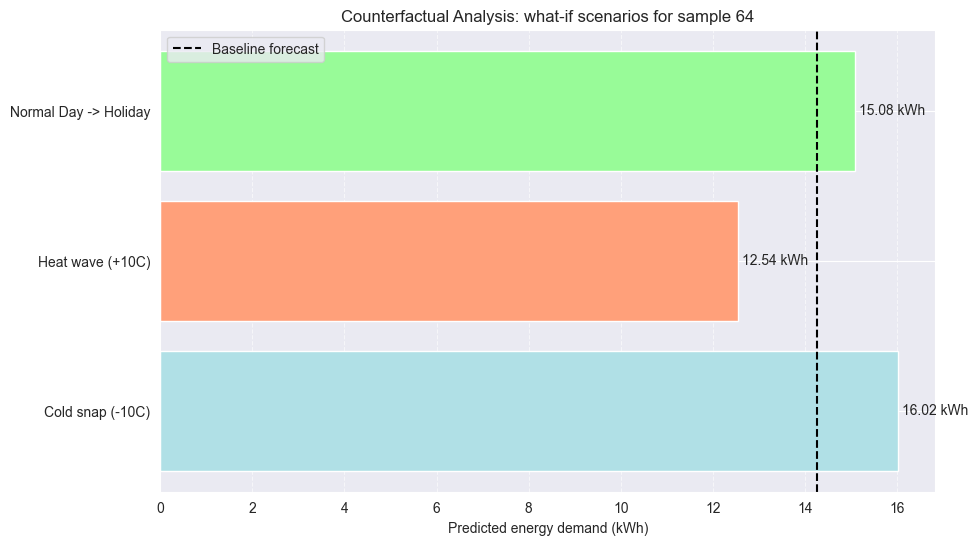

In [36]:
def rescale_val(scaler, val, n_features, is_contribution=False):
    """Helper to map scaled values back to kWh."""
    dummy = np.zeros((1, n_features))
    dummy[0, 0] = val
    rescaled = scaler.inverse_transform(dummy)[0, 0]
    if is_contribution:
        zero_dummy = np.zeros((1, n_features))
        return rescaled - scaler.inverse_transform(zero_dummy)[0, 0]
    return rescaled

def run_counterfactual_scenarios(model, Xp, Xf, scaler, past_names, future_names, sample_idx=25):
    """
    Simulates various what-if scenarios for a single instance to test model sensitivity.
    """
    model.eval()
    n_features = scaler.n_features_in_
    
    temp_idx = past_names.index('temperature')
    holiday_idx = future_names.index('is_holiday_or_weekend_True')
    pv_idx = past_names.index('pv')
    
    orig_xp = torch.tensor(Xp[sample_idx:sample_idx+1]).float()
    orig_xf = torch.tensor(Xf[sample_idx:sample_idx+1]).float()
    
    with torch.no_grad():
        base_pred = rescale_val(scaler, model(orig_xp, orig_xf).item(), n_features)

    scenarios = {}

    temp_idx = list(feat_names).index('temperature')

    temp_range = scaler.data_range_[temp_idx]
    physical_delta = 0.33 * temp_range
    print(f"training temp range: {temp_range:.2f}°C")
    print(f"0.33 shift : {physical_delta:.2f}°C")


    # Scenario 1: colder last 2 days (-0.33 scaled shift - about -10C)
    xp_cold = orig_xp.clone()
    xp_cold[:, :, temp_idx] -= 0.33 
    with torch.no_grad():
        scenarios["Cold snap (-10C)"] = rescale_val(scaler, model(xp_cold, orig_xf).item(), n_features)

    # Scenario 2: Heat wave
    xp_heat = orig_xp.clone()
    xp_heat[:, :, temp_idx] += 0.33
    with torch.no_grad():
        scenarios["Heat wave (+10C)"] = rescale_val(scaler, model(xp_heat, orig_xf).item(), n_features)

    # Scenario 3: Holiday Flip (If it was a holiday, make it a workday and opposite)
    xf_flip = orig_xf.clone()
    is_holiday = xf_flip[0, 0, holiday_idx].item() > 0.5
    xf_flip[0, 0, holiday_idx] = 0.0 if is_holiday else 1.0
    label = "Normal Day -> Holiday" if not is_holiday else "Holiday -> Normal Day"
    with torch.no_grad():
        scenarios[label] = rescale_val(scaler, model(orig_xp, xf_flip).item(), n_features)

    names = list(scenarios.keys())
    values = list(scenarios.values())

    plt.figure(figsize=(10, 6))
    bars = plt.barh(names, values, color = ["powderblue", "lightsalmon", "palegreen"])
    plt.axvline(base_pred, color='black', linestyle='--', label='Baseline forecast')
    plt.bar_label(bars, padding=3, fmt='%.2f kWh')
    plt.title(f"Counterfactual Analysis: what-if scenarios for sample {sample_idx}")
    plt.xlabel("Predicted energy demand (kWh)")
    plt.legend()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()


    return scenarios

def run_interpretability(run_id, model_class = LSTMAttentionModel, sample_indices=[0, 12, 30, 60, 64]):
    """ Analyze predicitons from run logged in wandb using shap and counterfactual explainantions"""

    run, config, Xp, Xf, df_logged, scaler, feat_names, state_dict = log_run_data(run_id)

    model = model_class(input_size=Xp.shape[1], n_past_features=Xp.shape[2], n_future_features=Xf.shape[2], **config["model"]["network_params"])
    model.load_state_dict(state_dict)
    model.eval()

    n_features = scaler.n_features_in_
    future_feat_names = feat_names[-4:].tolist()
    past_feat_names = feat_names[:-4].tolist()
    all_feature_names = feat_names.tolist() + future_feat_names #past features for both lags + future only
    rescale_factor = scaler.data_range_[0]

    bg_p, bg_f = torch.tensor(Xp).float(), torch.tensor(Xf).float()
    explainer = shap.GradientExplainer(model, [bg_p, bg_f])
    
    test_p, test_f = torch.tensor(Xp).float(), torch.tensor(Xf).float()
    shap_values = explainer.shap_values([test_p, test_f])
    
    past_shap_summed = (shap_values[0][:, -1, :] + shap_values[0][:, -2, :]).reshape(len(Xp), -1) #lag1+lag2
    future_shap = shap_values[1].reshape(len(Xf), -1)
    
    global_shap_kwh = np.concatenate([past_shap_summed, future_shap], axis=1)*rescale_factor
    global_data = np.concatenate([Xp[:, -1, :], Xf[:, 0, :]], axis=1)

    shap.summary_plot(global_shap_kwh, global_data, feature_names=all_feature_names, plot_type="bar", show=False, plot_size=(20,10))
    plt.title("summed lagged (t-1, t-2) and future features")
    plt.show()
    
    target_f = ['energy_demand', 'heat_pump', 'temperature', 'is_holiday_or_weekend_True']
    target_idx = [all_feature_names.index(f) for f in target_f if f in all_feature_names]
    exp_beeswarm = shap.Explanation(values=global_shap_kwh[:, target_idx], 
                                     data=global_data[:, target_idx], 
                                     feature_names=target_f)
    shap.plots.beeswarm(exp_beeswarm, show=False)
    plt.title("Feature Sensitivity")
    plt.show()


    # attention 
    with torch.no_grad():
        _, weights = model(test_p, test_f, return_attn=True)
    avg_attention = weights.squeeze().mean(dim=0).cpu().numpy()
    
    plt.figure(figsize=(8, 4))
    plt.bar([f"Lag {i+1}" for i in range(len(avg_attention))], avg_attention)
    plt.title(f"Model Temporal Attention")
    plt.grid()
    print("Avg attention", avg_attention)
    plt.ylabel("Attention Score")
    plt.show()

    #individual predicitons
    with torch.no_grad():
        raw_base = model(bg_p, bg_f).mean().item()
    kwh_base = rescale_val(scaler, raw_base, n_features)

    for idx in sample_indices:
        print(f"\nInstance {idx}")
        row = df_logged.iloc[idx]
        
        exp_instance = shap.Explanation(values=global_shap_kwh[idx], base_values=kwh_base, 
                                         data=global_data[idx], feature_names=all_feature_names)
        plt.figure(figsize=(12, 5))
        shap.plots.waterfall(exp_instance, show=False)
        plt.title(f"Local impact (kWh) - Date: {row['date']}")
        plt.show()
        instance_df = df_logged.iloc[[idx]].copy()
        for f_name, f_val in zip(all_feature_names, global_data[idx]):
            instance_df[f"norm_{f_name}"] = f_val
        display(instance_df.T)
        #counterfactual
        run_counterfactual_scenarios(model, Xp, Xf, scaler, past_feat_names, future_feat_names, sample_idx=idx)

run_interpretability("n3viomoq")